In [1]:
import pandas as pd
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)






In [2]:
import os
from dotenv import load_dotenv
import pandas as pd

load_dotenv()

print(os.getenv("CUSTOMER_DATA_PATH"))
print(os.getenv("PRODUCT_DATA_PATH"))

df1 = pd.read_csv(os.getenv("CUSTOMER_DATA_PATH"))
df2 = pd.read_csv(os.getenv("PRODUCT_DATA_PATH"))

print("Loaded successfully ✅")


../data/customer_behavior.csv
../data/products.csv
Loaded successfully ✅


In [3]:
# Insert into PostgreSQL tables
df2.to_sql("products", engine, if_exists="replace", index=False)
df1.to_sql("customer_behavior_raw", engine, if_exists="replace", index=False)

print("Data loaded successfully.")


Data loaded successfully.


In [5]:
df1.info()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 60 columns):
 #   Column                           Non-Null Count    Dtype 
---  ------                           --------------    ----- 
 0   user_id                          1000000 non-null  int64 
 1   age                              1000000 non-null  int64 
 2   gender                           1000000 non-null  object
 3   country                          1000000 non-null  object
 4   urban_rural                      1000000 non-null  object
 5   income_level                     1000000 non-null  int64 
 6   employment_status                1000000 non-null  object
 7   education_level                  1000000 non-null  object
 8   relationship_status              1000000 non-null  object
 9   has_children                     1000000 non-null  int64 
 10  household_size                   1000000 non-null  int64 
 11  occupation                       1000000 non-null  object
 12  e

In [6]:
df1.columns
df2.columns

Index(['product_id', 'product_name', 'price', 'category'], dtype='object')

In [7]:
df_clean= df1.copy()

In [8]:
features = [
    'user_id',
    'product_category_preference',
    'weekly_purchases',
    'monthly_spend',
    'average_order_value',
    'cart_abandonment_rate',
    'browse_to_buy_ratio',
    'return_frequency'
]

df_reco = df_clean[features]
df_reco.head()

,user_id,product_category_preference,weekly_purchases,monthly_spend,average_order_value,cart_abandonment_rate,browse_to_buy_ratio,return_frequency
0,1,Groceries,4,2405,445,0,12,1
1,2,Groceries,13,3651,179,28,93,12
2,3,Beauty,10,2045,26,14,68,5
3,4,Groceries,16,1611,403,11,74,2
4,5,Groceries,17,3476,68,57,34,12


In [10]:
#spend levels

df_reco =df1[features].copy()

df_reco['spend_level'] = pd.cut(
    df_reco['monthly_spend'],
    bins=[0, 2000, 5000, 10000],
    labels=['Low', 'Medium', 'High']
)



In [13]:
#recommendation function
def recommended_top_categories():
    return
df_reco['product_category_preference'].value_counts().head(3)

product_category_preference
Beauty         125409
Sports         125227
Electronics    125074
Name: count, dtype: int64

In [14]:
#spend-based Recommendation
def recommend_by_spend(spend_level, top_n=2):
    return (
        df_reco[df_reco['spend_level'] == spend_level]
        ['product_category_preference']
        .value_counts()
        .head(top_n)
    )

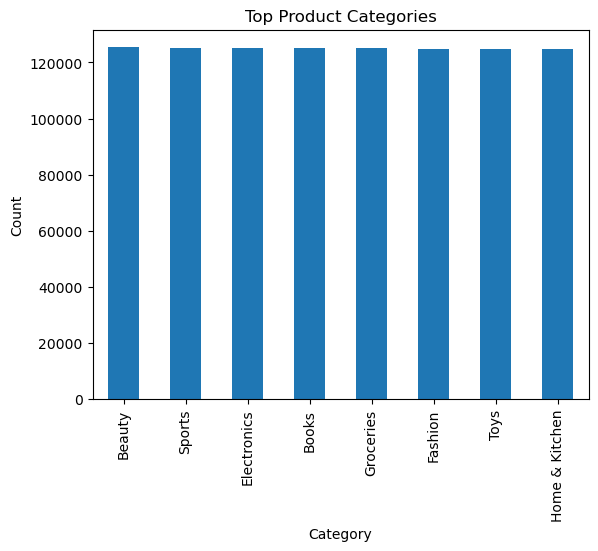

In [15]:
#Visualization
import matplotlib.pyplot as plt

top_categories = df_reco['product_category_preference'].value_counts()

top_categories.plot(kind='bar')
plt.title('Top Product Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

In [ ]:
pd.crosstab(
    df_reco['spend_level'],
    df_reco['product_category_preference']
)

In [ ]:
# Insight:
# Medium spend users form the majority and prefer categories like Groceries and Beauty.
# This information can be used to prioritize recommendations for mid-spend users.

In [ ]:
df_reco.groupby('spend_level')['average_order_value'].mean()


In [ ]:
df_reco.groupby('spend_level')['product_category_preference'] \
       .value_counts() \
       .groupby(level=0) \
       .head(2)

In [ ]:
def recommend_by_spend(spend_level, top_n=2):
    recommendations = (
        df_reco[df_reco['spend_level'] == spend_level]
        ['product_category_preference']
        .value_counts()
        .head(top_n)
    )
    return recommendations

In [16]:
recommend_by_spend('Medium')

product_category_preference
Groceries      75077
Electronics    74979
Name: count, dtype: int64

In [17]:
recommend_by_spend('Low')
recommend_by_spend('High')

Series([], Name: count, dtype: int64)

In [ ]:
# This function recommends product categories based on user spending level.
# It can be used as a simple rule-based recommendation system.

## Phase 1 – ETL Pipeline

### Extract
Data was extracted from:
1. A CSV dataset containing e-commerce shopper behavior.
2. A public e-commerce API (Fake Store API) using Python requests.